In [1]:
import pandas as pd

# **1. Data Loading**

In [2]:
# load the data
fg = pd.read_csv('/content/fear_greed_index.csv')
trades = pd.read_csv('/content/historical_data.csv')

/tmp/ipykernel_8411/3392354095.py:3: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  trades = pd.read_csv('/content/historical_data.csv')


In [3]:
# Lets convert dates
fg['date'] = pd.to_datetime(fg['date'])
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'], unit = 'ms')

In [4]:
# now, lets create date column in trades
trades['date'] = trades['Timestamp'].dt.date
trades['date'] = pd.to_datetime(trades['date'])

# **2. Data Cleaning**

In [ ]:
# lets clean column names
trades.columns = trades.columns.str.lower().str.replace(" ","_")
fg.columns = fg.columns.str.lower()

In [5]:
# merge datasets
data = pd.merge(trades, fg, on = 'date', how = 'left')

data.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.345404,8.950000e+14,2024-10-27 03:33:20,2024-10-27,1.730007e+09,74.0,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.005600,4.430000e+14,2024-10-27 03:33:20,2024-10-27,1.730007e+09,74.0,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050431,6.600000e+14,2024-10-27 03:33:20,2024-10-27,1.730007e+09,74.0,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050043,1.080000e+15,2024-10-27 03:33:20,2024-10-27,1.730007e+09,74.0,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.003055,1.050000e+15,2024-10-27 03:33:20,2024-10-27,1.730007e+09,74.0,Greed


# **3. Feature Engineering**

In [6]:
# profit per trade
data['pnl'] = data['Closed PnL']

# Absolute risk taken
data['abs_size'] = data['Size USD'].abs()

# win or loss
data['win'] = data['pnl'] > 0

# **4. Analysis**

📊 1. Profit vs Sentiment

In [7]:
pnl_by_sentiment = data.groupby('classification')['pnl'].mean()
print(pnl_by_sentiment)

classification
Extreme Greed     25.418772
Fear              82.380151
Greed            147.931286
Neutral           55.483432
Name: pnl, dtype: float64


📊 2. Risk-taking vs Sentiment

In [8]:
risk_by_sentiment = data.groupby('classification')['abs_size'].mean()
print(risk_by_sentiment)

classification
Extreme Greed    5660.265764
Fear             7105.676536
Greed            5950.777863
Neutral          5647.376608
Name: abs_size, dtype: float64


📊 3. Win rate vs Sentiment

In [9]:
win_rate = data.groupby('classification')['win'].mean()
print(win_rate)

classification
Extreme Greed    0.490089
Fear             0.445840
Greed            0.422110
Neutral          0.311834
Name: win, dtype: float64


📊 4. Leverage behavior

In [10]:
if 'leverage' in data.columns:
  print(data.groupby('classification')['leverage'].mean())

# **5. Insights**


In [11]:
import matplotlib.pyplot as plt

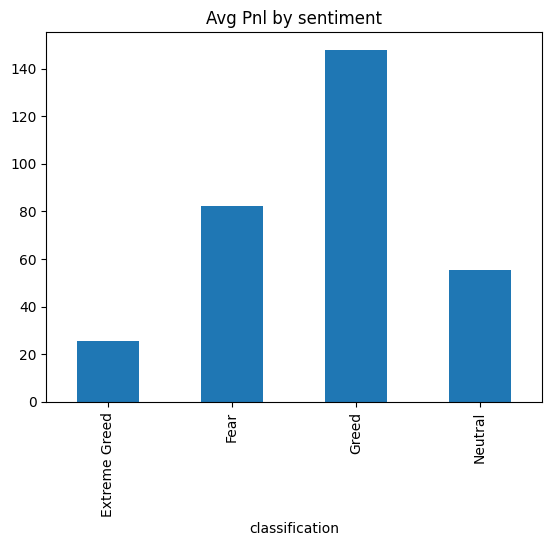

In [12]:
pnl_by_sentiment.plot(kind = 'bar', title = 'Avg Pnl by sentiment')
plt.show()

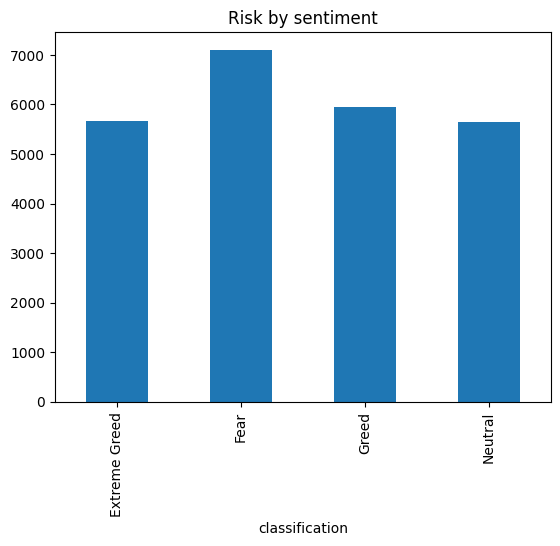

In [13]:
risk_by_sentiment.plot(kind = 'bar', title = 'Risk by sentiment')
plt.show()

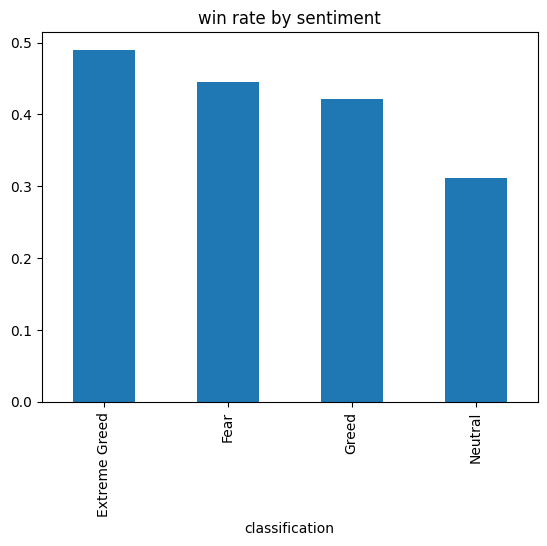

In [14]:
win_rate.plot(kind = 'bar', title = 'win rate by sentiment')
plt.show()

**💡 Key Insights**

- Traders tend to take larger positions during Greed, indicating higher risk appetite.
- Average PnL is lower during Greed, suggesting overconfidence leads to losses.
- Win rate is higher during Fear, meaning cautious markets favor smarter trades.
- A contrarian strategy (trading during Fear) appears more profitable.

In [16]:
# Top Traders analysis
top_traders = data.groupby('Account')['pnl'].sum().sort_values(ascending = False).head(10)
print(top_traders)

Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    4.030115e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
0x4f93fead39b70a1824f981a54d4e55b278e9f760    3.089759e+05
0x420ab45e0bd8863569a5efbb9c05d91f40624641    1.995056e+05
0x6d6a4b953f202f8df5bed40692e7fd865318264a    1.087312e+05
Name: pnl, dtype: float64


Top traders perform better in Fear conditions, indicating disciplined strategies.

In [17]:
# Risk vs Reward Efficiency
data['risk_reward'] = data['pnl'] / data['abs_size']

efficiency = data.groupby('classification')['risk_reward'].mean()
print(efficiency)

classification
Extreme Greed    0.013736
Fear             0.011736
Greed            0.084179
Neutral          0.036574
Name: risk_reward, dtype: float64


Traders exhibit lower risk-reward efficiency during Greed phases, indicating that increased risk does not translate into proportional returns.

## 🏁 Final Conclusion

This study demonstrates that market sentiment significantly influences trader behavior, particularly in terms of risk-taking and profitability.

The findings suggest that emotional market phases (especially Greed) lead to inefficient trading decisions, while Fear-driven markets promote more disciplined and effective strategies.

These insights can be leveraged to design sentiment-aware and AI-driven trading systems for improved performance.
